In [21]:
import numpy as np
import pandas as pd
# from scipy.interpolate import UnivariateSpline
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy import stats
from scipy.stats import norm
from scipy.optimize import curve_fit

In [22]:
%run ../codes/data_input.py
%run ../codes/mcmc_fun.py
%run ../codes/SEIVR.py
%run ../codes/curve_prepare.py

In [23]:
M_death_37_wk = np.loadtxt('deaths_37_phase2_v2.csv', delimiter=',')
# M_death_06_cum = np.cumsum(M_death_06_wk, axis=0)
M_case_37_wk = np.loadtxt('cases_37.csv', delimiter=',')
# M_case_06_cum = np.cumsum(M_death_06_wk, axis=0)

FileNotFoundError: deaths_37_phase2_v3.csv not found.

In [5]:
death_m = np.zeros((9,4))
for m_i in range(9):
    check = M_death_37_wk[10+m_i*4:10+(m_i+1)*4,:]
    print(check.shape)
    death_m[m_i,:] = np.sum(check,axis=0)

(4, 4)
(4, 4)
(4, 4)
(4, 4)
(4, 4)
(4, 4)
(4, 4)
(4, 4)
(4, 4)


In [6]:
death_real_shape = np.zeros((4,4))
death_real_shape[0,:] = np.sum(death_m[:6,:],axis=0)
death_real_shape[1:,:] = death_m[6:6+3,:]

In [7]:
actural_inf_37 = (np.loadtxt('serology_infections_37_complete.csv')).reshape(3,4,18)

In [8]:
##### acculate death
death_real_shape = np.zeros((5,4)) # months * races 
death_real_shape[0,:] = np.sum(death_m[:5,:],axis=0)
death_real_shape[1:,:] = death_m[5:5+4,:].cumsum(axis=0)

IFR_real_shape_37 = np.zeros((3,5,4)) ## month 3-8, 9 ,10, 11

### mean value of IFR
for j in range(3):
    IFR_real_shape_37[j,0,:] = death_real_shape[0,:]/actural_inf_37[j,:,0]
    for i in range(1,5):
        IFR_real_shape_37[j,i,:] = death_real_shape[i,:]/actural_inf_37[j,:,i]

/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_45616/1938923230.py:10: RuntimeWarning: divide by zero encountered in divide
  IFR_real_shape_37[j,0,:] = death_real_shape[0,:]/actural_inf_37[j,:,0]
/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_45616/1938923230.py:12: RuntimeWarning: divide by zero encountered in divide
  IFR_real_shape_37[j,i,:] = death_real_shape[i,:]/actural_inf_37[j,:,i]


In [9]:
IFR_real_shape_37[0]

array([[       inf, 0.01190241, 0.01905187, 0.00638983],
       [0.00014191, 0.00405884, 0.0026968 , 0.00074229],
       [0.00081872, 0.00539158, 0.02227558, 0.00094643],
       [0.00084027, 0.00653205, 0.00632181, 0.00155817],
       [       inf, 0.00558221, 0.00383891, 0.00126135]])

In [10]:
IFR_real_shape_37[1]

array([[       inf, 0.01785362, 0.06191857, 0.02748085],
       [0.00053217, 0.00575002, 0.00663828, 0.00157033],
       [0.00532169, 0.00667529, 0.17820467, 0.00190683],
       [0.00266084, 0.00803944, 0.01359188, 0.00412213],
       [       inf, 0.00651258, 0.00677044, 0.00258748]])

In [11]:
IFR_real_shape_37[2]

array([[7.06786838e-04, 8.40170262e-03, 5.05457733e-03, 2.74808537e-03],
       [4.34423603e-05, 2.87501011e-03, 1.18215975e-03, 4.75422371e-04],
       [1.57679678e-04, 4.38065874e-03, 3.96010381e-03, 6.35611583e-04],
       [2.75259783e-04, 5.22563914e-03, 3.02041816e-03, 8.96114796e-04],
       [4.33160744e-04, 4.80928935e-03, 2.24321934e-03, 8.56009408e-04]])

In [12]:
my_ifr = np.array([[       0, 0.01190241, 0.01905187, 0.00638983],
       [0.00014191, 0.00405884, 0.0026968 , 0.00074229],
       [0.00081872, 0.00539158, 0.02227558, 0.00094643],
       [0.00084027, 0.00653205, 0.00632181, 0.00155817],
       [       0, 0.00558221, 0.00383891, 0.00126135]])

In [13]:
my_ifr_ts = np.zeros((28*9,4))
my_ifr_ts[:28*5] = my_ifr[0]
my_ifr_ts[28*5:28*6] = my_ifr[1]
my_ifr_ts[28*6:28*7] = my_ifr[2]
my_ifr_ts[28*7:28*8] = my_ifr[3]
my_ifr_ts[28*8:28*9] = my_ifr[4]

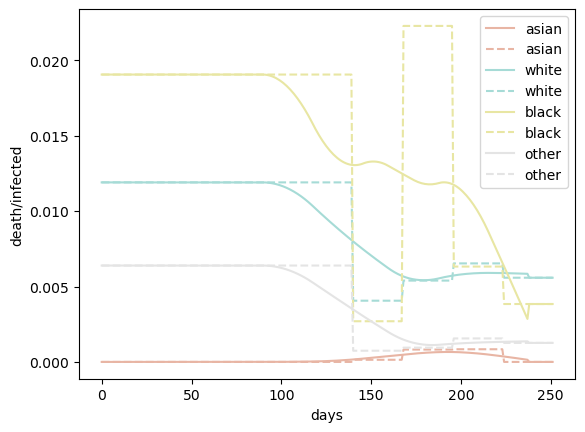

In [14]:
from scipy.signal import savgol_filter
def moving_average(data, window_size):
    """ Compute moving average """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
def exponential_moving_average(data, alpha):
    """ Compute exponential moving average """
    ema = []
    for point in data:
        if not ema:
            ema.append(point)
        else:
            ema.append(alpha * point + (1 - alpha) * ema[-1])
    return np.array(ema)
temp_v3 = np.zeros_like(my_ifr_ts) 
for r_idx in range(4):
    r = race_list_37[r_idx]
    # temp = moving_average(my_ifr_ts[:,r_idx],28)
    temp = savgol_filter(my_ifr_ts[:,r_idx], window_length=70, polyorder=1)
    temp2 = moving_average(temp,28)
    temp3 = np.zeros(my_ifr_ts.shape[0])
    temp3[13:-14] = temp2
    temp3[:14] = temp[:14]
    temp3[-14:] = my_ifr_ts[-14:,r_idx]
    temp_v3[:,r_idx] = temp3
    # temp = exponential_moving_average(my_ifr_ts[:,r_idx],0.5)
    # plt.plot(temp,label=r,c=custom_colors[r])
    plt.plot(temp3,label=r,c=custom_colors[r])
    # plt.plot(temp2,label=r,c=custom_colors[r])
    plt.plot(my_ifr_ts[:,r_idx],'--',label=r,c=custom_colors[r])
plt.ylabel('death/infected')
plt.xlabel('days')
plt.legend()

In [20]:
np.savetxt('my_ifr_ts-v4_37.csv',temp_v3)